In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import sys
from pathlib import Path

os.environ["TF_USE_LEGACY_KERAS"] = "1"
# Update this to the repo location in your Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown")
os.chdir(PROJECT_ROOT)
%pip install -r requirements.txt

FINE_TUNING_DIR = PROJECT_ROOT / "fine-tuning"

# Dataset paths (fixed layout under PROJECT_ROOT)
LABEL_FILE_NAME = "_annotation.wireframe.json"
DATASET_ROOT = PROJECT_ROOT / "dataset"
TRAIN_IMAGE_DIR = DATASET_ROOT / "train"
TRAIN_LABEL_PATH = TRAIN_IMAGE_DIR / LABEL_FILE_NAME
VAL_IMAGE_DIR = DATASET_ROOT / "valid"
VAL_LABEL_PATH = VAL_IMAGE_DIR / LABEL_FILE_NAME
TEST_IMAGE_DIR = DATASET_ROOT / "test"
TEST_LABEL_PATH = TEST_IMAGE_DIR / LABEL_FILE_NAME

In [4]:
# Verify TensorFlow sees a GPU
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

physical_gpus = tf.config.list_physical_devices("GPU")
print("Physical GPUs:", physical_gpus)

if physical_gpus:
    try:
        for gpu in physical_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices("GPU")
        print("Logical GPUs:", logical_gpus)
        print("GPU is available and configured.")
    except RuntimeError as exc:
        print("GPU detected but could not set memory growth:", exc)
else:
    print("No GPU detected. Check Colab runtime settings.")


TensorFlow version: 2.20.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPU is available and configured.


In [5]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    model_type: str = "M-LSD_512_large"
    ckpt_dir: str = ""
    save_dir: str = ""

    # --- Paper settings (AAAI 2022) scaled to 50 epochs ---
    # batch=64→8: lr = 0.01 * (8/64) = 0.00125
    # warmup: 5/150 * 50 ≈ 2 epochs
    # decay_start: 70/150 * 50 ≈ 23 epochs
    batch_size: int = 8
    epochs: int = 50
    learning_rate: float = 0.00125

    warmup_epochs: int = 2
    decay_start_epoch: int = 23
    eval_every: int = 5

    loss_weight_cls: float = 1.0
    loss_weight_reg: float = 1.0
    augment: bool = True

config = TrainConfig()
config.ckpt_dir = str(PROJECT_ROOT / "ckpt_models" / f"{config.model_type}")
config.save_dir = str(PROJECT_ROOT / "fine-tuned_model" / f"{config.model_type}_ft_{config.epochs}_000125")
os.makedirs(config.save_dir, exist_ok=True)
print(config)


TrainConfig(model_type='M-LSD_512_large', ckpt_dir='/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/ckpt_models/M-LSD_512_large', save_dir='/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/fine-tuned_model/M-LSD_512_large_ft_50_000125', batch_size=8, epochs=50, learning_rate=0.00125, warmup_epochs=2, decay_start_epoch=23, eval_every=5, loss_weight_cls=1.0, loss_weight_reg=1.0, augment=True)


In [6]:
os.chdir(FINE_TUNING_DIR)
%pwd

'/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/fine-tuning'

In [7]:
import json
import math
from dataclasses import dataclass
from typing import List, Tuple

import tensorflow as tf

import dataloader as dl
import load_model


def setup_gpu() -> None:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy("float32")


def load_labels(label_path: str, image_dir: str) -> Tuple[List[str], List[List[List[float]]]]:
    if not os.path.isfile(label_path):
        raise FileNotFoundError(f"Label json not found: {label_path}")

    with open(label_path, "r", encoding="utf-8") as f:
        labels = json.load(f)

    image_paths = []
    lines_list = []
    for item in labels:
        filename = item.get("filename")
        lines = item.get("lines", [])
        if not filename:
            continue
        image_paths.append(os.path.join(image_dir, filename))
        lines_list.append(lines)

    if not image_paths:
        raise ValueError("No labels found in label json.")

    return image_paths, lines_list


def get_lr(epoch: int, config: TrainConfig) -> float:
    if epoch < config.warmup_epochs:
        return config.learning_rate * (epoch / max(1, config.warmup_epochs))
    if epoch < config.decay_start_epoch:
        return config.learning_rate

    progress = (epoch - config.decay_start_epoch) / max(1, config.epochs - config.decay_start_epoch)
    return 0.5 * config.learning_rate * (1.0 + math.cos(math.pi * progress))


# ---------------------------------------------------------------------------
# Loss primitives
# ---------------------------------------------------------------------------

def _wbce_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    """Weighted Binary Cross-Entropy with dynamic pos_weight.

    Paper: WBCE is used for center maps (TP & SoL), junction map, and line map
    to handle the heavy class imbalance between background and foreground pixels.
    pos_weight = (# negative pixels) / (# positive pixels) is computed per batch.
    """
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    n_pos = tf.reduce_sum(y_true_f) + 1e-6
    n_total = tf.cast(tf.size(y_true_f), tf.float32)
    pos_weight = (n_total - n_pos) / n_pos
    loss = tf.nn.weighted_cross_entropy_with_logits(y_true_f, y_pred_f, pos_weight)
    return tf.reduce_mean(loss)


def _masked_huber(
    y_true: tf.Tensor,
    y_pred: tf.Tensor,
    mask: tf.Tensor,
    huber: tf.keras.losses.Huber,
) -> tf.Tensor:
    """Smooth L1 (Huber) loss restricted to masked positions."""
    true_vals = tf.boolean_mask(y_true, mask)
    pred_vals = tf.boolean_mask(y_pred, mask)
    return tf.cond(
        tf.size(true_vals) > 0,
        lambda: tf.reduce_mean(huber(true_vals, pred_vals)),
        lambda: tf.constant(0.0, dtype=tf.float32),
    )


def _masked_l1(
    y_true: tf.Tensor,
    y_pred: tf.Tensor,
    mask: tf.Tensor,
) -> tf.Tensor:
    """L1 loss restricted to masked positions (used for matching loss)."""
    true_vals = tf.boolean_mask(y_true, mask)
    pred_vals = tf.boolean_mask(y_pred, mask)
    return tf.cond(
        tf.size(true_vals) > 0,
        lambda: tf.reduce_mean(tf.abs(true_vals - pred_vals)),
        lambda: tf.constant(0.0, dtype=tf.float32),
    )


# ---------------------------------------------------------------------------
# Main loss function — paper-aligned structure
# ---------------------------------------------------------------------------

def compute_loss(
    y_true: tf.Tensor,
    y_pred: tf.Tensor,
    config: TrainConfig,
) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    """Compute the M-LSD training loss.

    Paper formula (Eq. 5):
        L_total = L_TP + L_SoL + L_Geo

        L_TP  = L_center(WBCE) + L_disp(SmoothL1) + L_match(L1)
        L_SoL = L_center(WBCE) + L_disp(SmoothL1) + L_match(L1)
        L_Geo = L_junc(WBCE) + L_line(WBCE) + L_length(SmoothL1) + L_degree(SmoothL1)

    Channel layout (matches generate_target_maps_np in dataloader.py):
      ch  0   : TP center heatmap       — WBCE (logits)
      ch  1   : TP length  [0,1]        — SmoothL1 at 3×3 window
      ch  2   : TP degree  [0,1]        — SmoothL1 at 3×3 window
      ch 3–4  : TP disp start (norm)    — SmoothL1 + L1 at center pixel
      ch 5–6  : TP disp end   (norm)    — SmoothL1 + L1 at center pixel
      ch  7   : SOL center heatmap      — WBCE (logits)
      ch 8–9  : SOL length/degree       — SmoothL1 at 3×3 window
      ch 10–13: SOL disp start/end(norm)— SmoothL1 + L1 at center pixel
      ch 14   : junction heatmap        — WBCE (logits)
      ch 15   : line segment map        — WBCE (logits)

    Displacement normalization note:
      Raw pixel displacements are divided by (map_size/2) in generate_target_maps_np
      to keep all regression targets in [-1, 1], preventing displacement collapse
      caused by Gaussian-tail pixels having zero displacement targets.
      The mask threshold > 0.9 restricts regression to the single center pixel
      (forced to 1.0), further preventing displacement collapse.

    Simplified matching loss:
      The paper's matching loss matches predicted lines to GT lines within γ=5 px
      and applies L1 on endpoint differences. Here we apply L1 directly at GT center
      positions (where the center pixel = 1.0), which avoids NMS during training
      while still providing the coupled endpoint signal described in the paper.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    huber = tf.keras.losses.Huber(reduction=tf.keras.losses.Reduction.NONE)

    # ----- Masks -----
    # Center pixel mask: threshold > 0.9 to exclude Gaussian-tail pixels
    # (center pixel is forced to 1.0 in generate_target_maps_np)
    mask_tp  = y_true[..., 0] > 0.9
    mask_sol = y_true[..., 7] > 0.9

    # Length/degree mask: 3×3 window written by _stamp_window (value > 0 when any line nearby)
    # Model applies sigmoid to dist/deg maps so predictions are already in [0,1]
    mask_tp_ld  = y_true[..., 1] > 0.0
    mask_sol_ld = y_true[..., 8] > 0.0

    # ----- L_TP = L_center + L_disp + L_match -----
    tp_center_loss = _wbce_loss(y_true[..., 0], y_pred[..., 0])
    tp_disp_loss   = _masked_huber(y_true[..., 3:7], y_pred[..., 3:7], mask_tp, huber)
    tp_match_loss  = _masked_l1(y_true[..., 3:7], y_pred[..., 3:7], mask_tp)
    l_tp = tp_center_loss + tp_disp_loss + tp_match_loss

    # ----- L_SoL = L_center + L_disp + L_match -----
    sol_center_loss = _wbce_loss(y_true[..., 7], y_pred[..., 7])
    sol_disp_loss   = _masked_huber(y_true[..., 10:14], y_pred[..., 10:14], mask_sol, huber)
    sol_match_loss  = _masked_l1(y_true[..., 10:14], y_pred[..., 10:14], mask_sol)
    l_sol = sol_center_loss + sol_disp_loss + sol_match_loss

    # ----- L_Geo = L_seg + L_reg -----
    # L_seg: WBCE for junction and line maps (logits)
    junc_loss = _wbce_loss(y_true[..., 14], y_pred[..., 14])
    line_loss = _wbce_loss(y_true[..., 15], y_pred[..., 15])

    # L_reg: SmoothL1 for length and degree (both in [0,1])
    tp_len_loss  = _masked_huber(y_true[..., 1:2], y_pred[..., 1:2], mask_tp_ld,  huber)
    tp_deg_loss  = _masked_huber(y_true[..., 2:3], y_pred[..., 2:3], mask_tp_ld,  huber)
    sol_len_loss = _masked_huber(y_true[..., 8:9],  y_pred[..., 8:9],  mask_sol_ld, huber)
    sol_deg_loss = _masked_huber(y_true[..., 9:10], y_pred[..., 9:10], mask_sol_ld, huber)

    l_geo = junc_loss + line_loss + tp_len_loss + tp_deg_loss + sol_len_loss + sol_deg_loss

    total_loss = l_tp + l_sol + l_geo

    # Logging breakdown
    cls_loss = tp_center_loss + sol_center_loss + junc_loss + line_loss
    reg_loss = (tp_disp_loss + tp_match_loss + sol_disp_loss + sol_match_loss
                + tp_len_loss + tp_deg_loss + sol_len_loss + sol_deg_loss)

    return total_loss, cls_loss, reg_loss


def to_train_map(preds: tf.Tensor) -> tf.Tensor:
    """Rearrange the 17-element model output into a [B, H, W, 16] tensor.

    Model output tuple (from Decoder.call in modules/models.py):
      preds[ 0] center_map       [B, H, W, 1]  SOL center heatmap (logits)
      preds[ 1] disp_map         [B, H, W, 4]  SOL displacement map (raw)
      preds[ 2] center_pts       [B, topk, 2]
      preds[ 3] center_scores    [B, topk]
      preds[ 4] disp_map_act     [B, H, W, 4]  (same as disp_map)
      preds[ 5] line_map         [B, H, W, 1]  line segment map (logits)
      preds[ 6] corner_map       [B, H, W, 1]  junction heatmap (logits)
      preds[ 7] corner_pts       [B, topk, 2]
      preds[ 8] corner_scores    [B, topk]
      preds[ 9] org_center_map   [B, H, W, 1]  TP center heatmap (logits)
      preds[10] org_disp_map     [B, H, W, 4]  TP displacement (raw)
      preds[11] org_center_pts   [B, topk, 2]
      preds[12] org_center_scores[B, topk]
      preds[13] org_dist_map     [B, H, W, 1]  TP length  (sigmoid applied → [0,1])
      preds[14] org_deg_map      [B, H, W, 1]  TP degree  (sigmoid applied → [0,1])
      preds[15] split_dist_map   [B, H, W, 1]  SOL length (sigmoid applied → [0,1])
      preds[16] split_deg_map    [B, H, W, 1]  SOL degree (sigmoid applied → [0,1])
    """
    if not isinstance(preds, (list, tuple)) or len(preds) != 17:
        return preds
    (
        center_map,
        disp_map,
        _center_pts,
        _center_scores,
        _disp_map_act,
        line_map,
        corner_map,
        _corner_pts,
        _corner_scores,
        org_center_map,
        org_disp_map,
        _org_center_pts,
        _org_center_scores,
        org_dist_map,
        org_deg_map,
        split_dist_map,
        split_deg_map,
    ) = preds
    tp_disp_start  = org_disp_map[:, :, :, 0:2]
    tp_disp_end    = org_disp_map[:, :, :, 2:4]
    sol_disp_start = disp_map[:, :, :, 0:2]
    sol_disp_end   = disp_map[:, :, :, 2:4]
    return tf.concat(
        [
            org_center_map,   # ch  0  TP center heatmap   (logits)
            org_dist_map,     # ch  1  TP length            (sigmoid → [0,1])
            org_deg_map,      # ch  2  TP degree            (sigmoid → [0,1])
            tp_disp_start,    # ch 3-4 TP disp start        (raw)
            tp_disp_end,      # ch 5-6 TP disp end          (raw)
            center_map,       # ch  7  SOL center heatmap   (logits)
            split_dist_map,   # ch  8  SOL length           (sigmoid → [0,1])
            split_deg_map,    # ch  9  SOL degree           (sigmoid → [0,1])
            sol_disp_start,   # ch 10-11 SOL disp start     (raw)
            sol_disp_end,     # ch 12-13 SOL disp end       (raw)
            corner_map,       # ch 14  junction heatmap     (logits)
            line_map,         # ch 15  line segment map     (logits)
        ],
        axis=-1,
    )


setup_gpu()

model_cfg = load_model.infer_config_from_path(config.ckpt_dir)
model_cfg.batch_size = config.batch_size
model = load_model.build_model(model_cfg)
load_model.load_checkpoint(model, config.ckpt_dir)


image_paths, lines_list = load_labels(str(TRAIN_LABEL_PATH), str(TRAIN_IMAGE_DIR))
dataset = dl.build_dataloader(
    image_paths=image_paths,
    lines_list=lines_list,
    batch_size=config.batch_size,
    target_size=model_cfg.input_size,
    augment=config.augment,
)

val_dataset = None
if os.path.isfile(str(VAL_LABEL_PATH)):
    val_image_paths, val_lines_list = load_labels(str(VAL_LABEL_PATH), str(VAL_IMAGE_DIR))
    val_dataset = dl.build_dataloader(
        image_paths=val_image_paths,
        lines_list=val_lines_list,
        batch_size=config.batch_size,
        target_size=model_cfg.input_size,
        augment=False,
    )

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0)
if tf.keras.mixed_precision.global_policy().compute_dtype == "float16":
    optimizer = tf.keras.mixed_precision.LossScaleOptimizer(optimizer)

ckpt = tf.train.Checkpoint(step=tf.Variable(0, name="step"), model=model)
manager = tf.train.CheckpointManager(ckpt, config.save_dir, max_to_keep=1)


@tf.function
def train_step(images: tf.Tensor, targets: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    with tf.GradientTape() as tape:
        preds = model(images, training=True)
        train_preds = to_train_map(preds)
        total_loss, cls_loss, reg_loss = compute_loss(targets, train_preds, config)

        if isinstance(optimizer, tf.keras.mixed_precision.LossScaleOptimizer):
            scaled_loss = optimizer.scale_loss(total_loss)
        else:
            scaled_loss = total_loss

    grads = tape.gradient(scaled_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss, cls_loss, reg_loss


@tf.function
def eval_step(images: tf.Tensor, targets: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    preds = model(images, training=False)
    train_preds = to_train_map(preds)
    total_loss, cls_loss, reg_loss = compute_loss(targets, train_preds, config)
    return total_loss, cls_loss, reg_loss


9406464/9406464 [==============================] - 0s 0us/step
[*] load ckpt from /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/ckpt_models/M-LSD_512_large/ckpt-151 at step 58500.


In [8]:
for epoch in range(config.epochs):
    lr = get_lr(epoch, config)
    optimizer.learning_rate.assign(lr)

    total_meter = tf.keras.metrics.Mean()
    cls_meter = tf.keras.metrics.Mean()
    reg_meter = tf.keras.metrics.Mean()

    for images, targets in dataset:
        total_loss, cls_loss, reg_loss = train_step(images, targets)
        total_meter.update_state(total_loss)
        cls_meter.update_state(cls_loss)
        reg_meter.update_state(reg_loss)

    log = (
        f"Epoch {epoch + 1}/{config.epochs} | lr={lr:.6f} | "
        f"loss={total_meter.result():.4f} | "
        f"cls={cls_meter.result():.4f} | reg={reg_meter.result():.4f}"
    )

    if val_dataset is not None and (epoch + 1) % config.eval_every == 0:
        val_total = tf.keras.metrics.Mean()
        val_cls = tf.keras.metrics.Mean()
        val_reg = tf.keras.metrics.Mean()
        for images, targets in val_dataset:
            total_loss, cls_loss, reg_loss = eval_step(images, targets)
            val_total.update_state(total_loss)
            val_cls.update_state(cls_loss)
            val_reg.update_state(reg_loss)
        log += (
            f" | val_loss={val_total.result():.4f}"
            f" | val_cls={val_cls.result():.4f}"
            f" | val_reg={val_reg.result():.4f}"
        )

    print(log)

    ckpt.step.assign_add(1)

final_checkpoint = manager.save()
print("Saved final checkpoint to:", final_checkpoint)

Epoch 1/50 | lr=0.000000 | loss=58.0442 | cls=11.7327 | reg=46.3115
Epoch 2/50 | lr=0.000625 | loss=38.4658 | cls=5.7780 | reg=32.6878
Epoch 3/50 | lr=0.001250 | loss=30.4446 | cls=2.2733 | reg=28.1714
Epoch 4/50 | lr=0.001250 | loss=27.8032 | cls=1.8760 | reg=25.9272
Epoch 5/50 | lr=0.001250 | loss=26.3838 | cls=1.7929 | reg=24.5909 | val_loss=26.7962 | val_cls=2.0450 | val_reg=24.7512
Epoch 6/50 | lr=0.001250 | loss=24.4277 | cls=1.7159 | reg=22.7118
Epoch 7/50 | lr=0.001250 | loss=22.4487 | cls=1.6566 | reg=20.7921
Epoch 8/50 | lr=0.001250 | loss=22.0505 | cls=1.6075 | reg=20.4430
Epoch 9/50 | lr=0.001250 | loss=21.2918 | cls=1.5822 | reg=19.7096
Epoch 10/50 | lr=0.001250 | loss=19.6703 | cls=1.5503 | reg=18.1200 | val_loss=19.6511 | val_cls=1.6757 | val_reg=17.9753
Epoch 11/50 | lr=0.001250 | loss=19.6756 | cls=1.5321 | reg=18.1436
Epoch 12/50 | lr=0.001250 | loss=18.5453 | cls=1.5220 | reg=17.0233
Epoch 13/50 | lr=0.001250 | loss=17.4340 | cls=1.5016 | reg=15.9324
Epoch 14/50 | lr

In [9]:
from dataclasses import dataclass


_OFFICIAL_MODEL_NAMES = {
    "M-LSD_320_tiny",
    "M-LSD_320_large",
    "M-LSD_512_tiny",
    "M-LSD_512_large",
}

@dataclass
class TestConfig:
    """Checkpoint path and inference settings for evaluation / visualization."""

    model_path: str = str(PROJECT_ROOT / "fine-tuned_model" / "M-LSD_512_large_ft_50_000125")

    input_size: int = 512
    backbone_type: str = "MLSD_large"

    num_samples: int = 5
    score_thr: float = 0.5
   # dist_thr is in map-space pixels (raw displacement).
    dist_thr: float = 10.0
    topk: int = 200


pretrained_test_config = TestConfig(
    model_path=str(PROJECT_ROOT / "ckpt_models" / config.model_type),
)

finetuned_test_config = TestConfig(
    model_path=config.save_dir,
)

test_config = finetuned_test_config

print("Pretrained:", pretrained_test_config)
print("Finetuned:", finetuned_test_config)


Pretrained: TestConfig(model_path='/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/ckpt_models/M-LSD_512_large', input_size=512, backbone_type='MLSD_large', num_samples=5, score_thr=0.5, dist_thr=10.0, topk=200)
Finetuned: TestConfig(model_path='/content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/fine-tuned_model/M-LSD_512_large_ft_50_000125', input_size=512, backbone_type='MLSD_large', num_samples=5, score_thr=0.5, dist_thr=10.0, topk=200)


In [10]:
import json
import os
from typing import List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import dataloader as dl
import load_model


def decode_lines_from_model_output(
    preds,
    input_size: int,
    score_thr: float,
    dist_thr: float,
    debug: bool = False,
    ) -> Tuple[np.ndarray, np.ndarray]:
    """Decode the 17-element model output tuple into line segments.

    Relevant indices (see Decoder.call in modules/models.py):
      preds[10] = org_disp_map      [B, H, W, 4]  TP displacement (dx_s, dy_s, dx_e, dy_e)
      preds[11] = org_center_pts    [B, topk, 2]  TP center points (y, x) after NMS
      preds[12] = org_center_scores [B, topk]     TP center scores
    """
    pts       = preds[11][0].numpy()   # [topk, 2]  (y, x)
    pts_score = preds[12][0].numpy()   # [topk]
    vmap      = preds[10][0].numpy()   # [H, W, 4]

    start    = vmap[:, :, :2]
    end      = vmap[:, :, 2:]
    dist_map = np.sqrt(np.sum((start - end) ** 2, axis=-1))

    if debug:
        # Overall statistics of the distance map
        print(
            f"    dist_map: min={dist_map.min():.4f}, max={dist_map.max():.4f}, "
            f"mean={dist_map.mean():.4f}"
)
        # Statistics of org_disp_map (raw displacement)
        print(f"    vmap(disp raw): min={vmap.min():.4f}, max={vmap.max():.4f}")
        # Distance at points where score > score_thr
        high_score_mask = pts_score > score_thr
        if high_score_mask.any():
            ys = pts[high_score_mask, 0].astype(int)
            xs = pts[high_score_mask, 1].astype(int)
            dists_at_pts = dist_map[ys, xs]
            print(
                f"    {high_score_mask.sum()} pts with score>{score_thr}: "
                f"dist min={dists_at_pts.min():.4f}, max={dists_at_pts.max():.4f}, "
                f"mean={dists_at_pts.mean():.4f}"
)
            print(f"    dist > {dist_thr}: {(dists_at_pts > dist_thr).sum()} pts pass")

    segments_list = []
    line_scores   = []
    for (y, x), score in zip(pts, pts_score):
        y, x     = int(y), int(x)
        distance = float(dist_map[y, x])
        if score > score_thr and distance > dist_thr:
            dx_s, dy_s, dx_e, dy_e = vmap[y, x]
            segments_list.append([x + dx_s, y + dy_s, x + dx_e, y + dy_e])
            line_scores.append(float(score))

    if not segments_list:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    lines = 2.0 * np.array(segments_list, dtype=np.float32)  # map -> input (x2)
    return lines, np.array(line_scores, dtype=np.float32)


def draw_lines_on_image(image_u8: np.ndarray, lines: np.ndarray, color=(0, 0, 255)) -> np.ndarray:
    """Draw detected lines on the image. Color is red by default. Lines are thick."""
    output = image_u8.copy()
    if output.ndim == 2:
        output = cv2.cvtColor(output, cv2.COLOR_GRAY2BGR)
    elif output.shape[2] == 1:
        output = cv2.cvtColor(output, cv2.COLOR_GRAY2BGR)
    if lines.shape[0] == 0:
        return output
    for x1, y1, x2, y2 in lines:
        h, w = output.shape[:2]
        x1 = np.clip(int(round(x1)), 0, w - 1)
        y1 = np.clip(int(round(y1)), 0, h - 1)
        x2 = np.clip(int(round(x2)), 0, w - 1)
        y2 = np.clip(int(round(y2)), 0, h - 1)
        cv2.line(output, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)
    return output


def model_cfg_from_test_config(config: TestConfig) -> load_model.ModelConfig:
    model_name = os.path.basename(os.path.normpath(config.model_path))
    if model_name in _OFFICIAL_MODEL_NAMES:
        model_cfg = load_model.infer_config_from_path(config.model_path)
        model_cfg.batch_size = 1
        model_cfg.topk = config.topk
        return model_cfg

    return load_model.ModelConfig(
        input_size=config.input_size,
        map_size=config.input_size // 2,
        backbone_type=config.backbone_type,
        batch_size=1,
        topk=config.topk,
    )


def load_model_from_test_config(config: TestConfig) -> Tuple[tf.keras.Model, load_model.ModelConfig]:
    model_cfg = model_cfg_from_test_config(config)
    model = load_model.build_model(model_cfg)
    load_model.load_checkpoint(model, config.model_path)
    return model, model_cfg


def run_inference_and_visualize(
    infer_config: TestConfig,
    title: str = "Inference",
    image_dir: str = None,
    label_path: str = None,
    ) -> None:
    """Run inference and visualize detected lines.

    Args:
        infer_config: TestConfig with model path and inference settings.
        title: Plot title.
        image_dir: Directory containing images. Defaults to TEST_IMAGE_DIR.
        label_path: Path to the annotation JSON. Defaults to TEST_LABEL_PATH.
    """
    if image_dir is None:
        image_dir = str(TEST_IMAGE_DIR)
    if label_path is None:
        label_path = str(TEST_LABEL_PATH)

    print(f"\n{'=' * 60}")
    print(title)
    print(f"model_path: {infer_config.model_path}")
    print(f"image_dir:  {image_dir}")
    print(f"score_thr={infer_config.score_thr}  dist_thr={infer_config.dist_thr}  topk={infer_config.topk}")
    print(f"{'=' * 60}")

    tf.keras.backend.clear_session()
    model, model_cfg = load_model_from_test_config(infer_config)

    img_paths, lines_list = load_labels(label_path, image_dir)
    dataset = dl.build_dataloader(
        image_paths=img_paths,
        lines_list=lines_list,
        batch_size=1,
        target_size=model_cfg.input_size,
        augment=False,
    )

    images_out = []
    line_counts = []

    for images, _targets in dataset:
        # model returns a 17-element tuple; decode_lines_from_model_output uses indices 10-12
        preds = model(images, training=False)

        image    = images[0].numpy()
        image_u8 = image.clip(0, 255).astype(np.uint8)

        is_first = len(images_out) == 0
        lines, line_scores = decode_lines_from_model_output(
            preds,
            model_cfg.input_size,
            score_thr=infer_config.score_thr,
            dist_thr=infer_config.dist_thr,
            debug=is_first,  # detailed debug only for the first image
        )
        if is_first:
            scores = preds[12][0].numpy()
            print(
                f"  scores: max={scores.max():.4f}, "
                f">{infer_config.score_thr}={(scores > infer_config.score_thr).sum()}, "
                f"lines_detected={len(lines)}"
)

        line_counts.append(len(lines))

        overlay = draw_lines_on_image(
            cv2.cvtColor(image_u8, cv2.COLOR_RGB2BGR),
            lines,
        )
        images_out.append(overlay)

        if len(images_out) >= infer_config.num_samples:
            break

    print(f"Lines per image: {line_counts}")

    if images_out:
        fig, axes = plt.subplots(1, len(images_out), figsize=(4 * len(images_out), 4))
        if len(images_out) == 1:
            axes = [axes]
        for ax, img in zip(axes, images_out):
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.axis("off")
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()

    del model
    tf.keras.backend.clear_session()



Pretrained model
model_path: /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/ckpt_models/M-LSD_512_large
image_dir:  /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/dataset/test
score_thr=0.5  dist_thr=10.0  topk=200
[*] load ckpt from /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/ckpt_models/M-LSD_512_large/ckpt-151 at step 58500.
    dist_map: min=0.2419, max=1757.3892, mean=98.1125
    vmap(disp raw): min=-878.5255, max=875.9690
    19 pts with score>0.5: dist min=12.2572, max=139.7459, mean=45.9108
    dist > 10.0: 19 pts pass
  scores: max=0.9569, >0.5=19, lines_detected=19
Lines per image: [19, 31, 14, 35, 11]


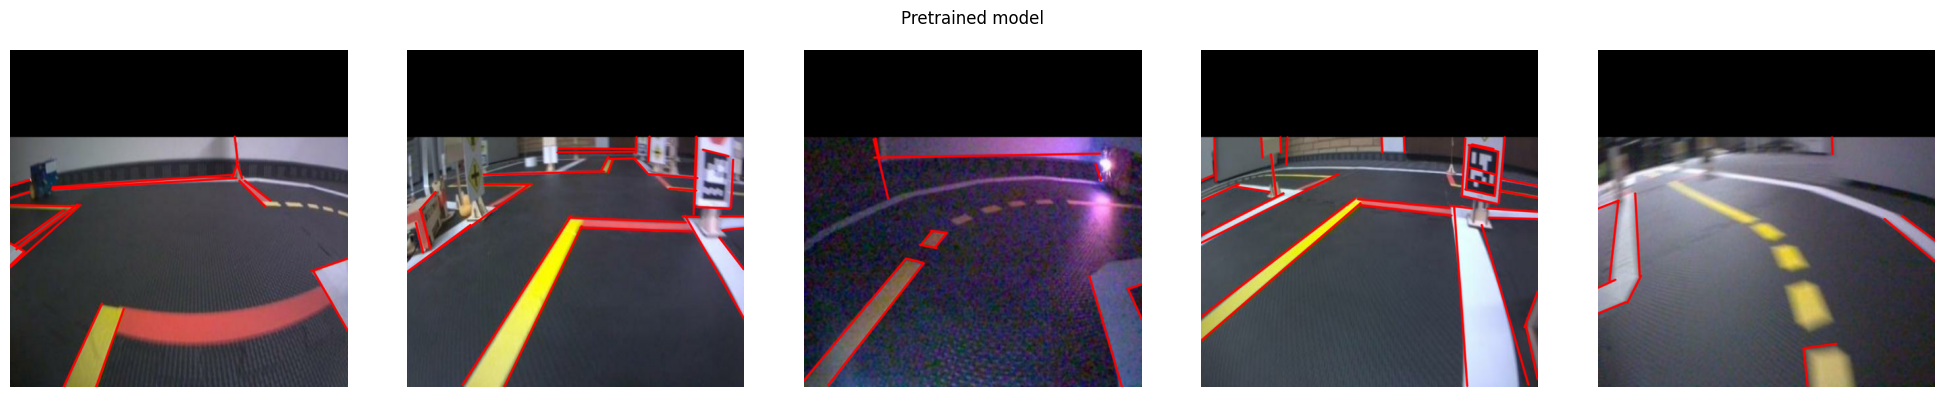


Fine-tuned model
model_path: /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/fine-tuned_model/M-LSD_512_large_ft_50_000125
image_dir:  /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/dataset/test
score_thr=0.5  dist_thr=10.0  topk=200
[*] load ckpt from /content/drive/MyDrive/Colab Notebooks/mlsd-for-duckitown/fine-tuned_model/M-LSD_512_large_ft_50_000125/ckpt-1 at step 50.
    dist_map: min=0.0872, max=1389.9896, mean=60.6114
    vmap(disp raw): min=-690.7436, max=697.5687
    184 pts with score>0.5: dist min=0.3364, max=84.8750, mean=24.1440
    dist > 10.0: 128 pts pass
  scores: max=0.9956, >0.5=184, lines_detected=128
Lines per image: [128, 92, 123, 135, 119]


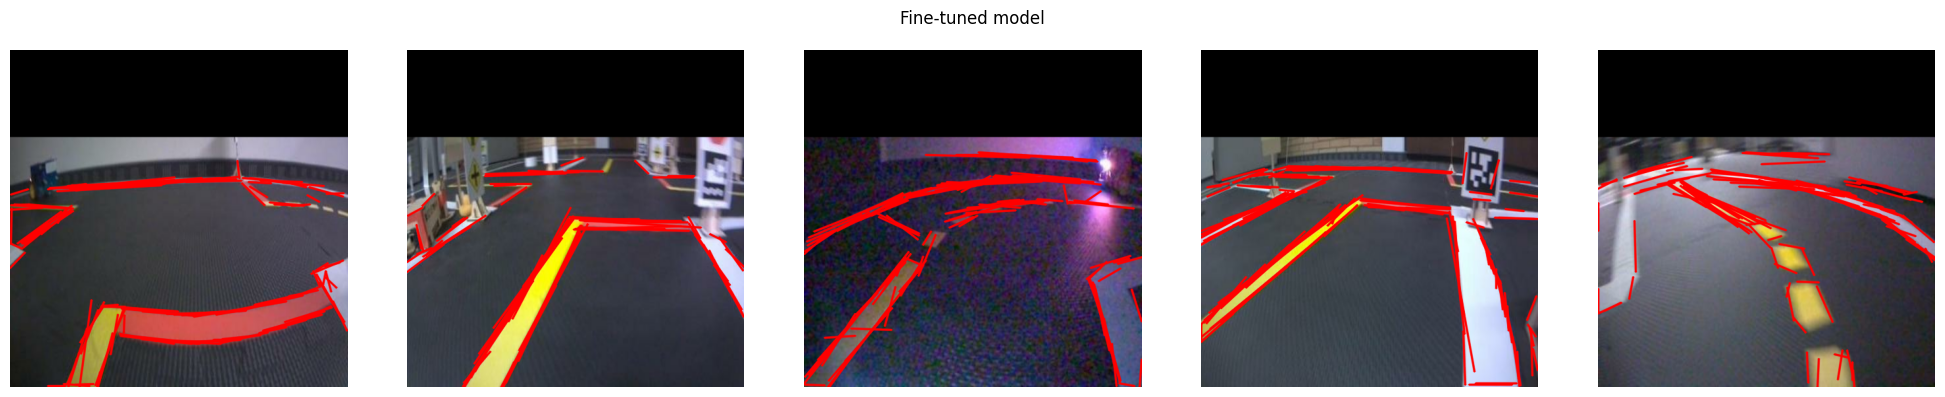

In [11]:
run_inference_and_visualize(
    pretrained_test_config,
    title="Pretrained model",
    # image_dir=str(TRAIN_IMAGE_DIR),
    # label_path=str(TRAIN_LABEL_PATH),
)

run_inference_and_visualize(
    finetuned_test_config,
    title="Fine-tuned model",
    # image_dir=str(TRAIN_IMAGE_DIR),
    # label_path=str(TRAIN_LABEL_PATH),
)
